In [1]:
# requirements: pandas numpy scikit-learn matplotlib seaborn joblib streamlit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib


In [3]:
df = pd.read_csv('../data/raw/single_genre_artists.csv')
df.shape, df.columns

((95837, 23),
 Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
        'id_artists', 'release_date', 'danceability', 'energy', 'key',
        'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
        'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
        'name_artists', 'popularity_artists'],
       dtype='object'))

In [4]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity_songs,95837.0,26.066394,16.254133,0.00000,13.0000,26.000000,37.0000,9.800000e+01
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4.800118e+06
explicit,95837.0,0.029644,0.169604,0.00000,0.0000,0.000000,0.0000,1.000000e+00
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,9.910000e-01
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000000e+00
key,95837.0,5.196782,3.534923,0.00000,2.0000,5.000000,8.0000,1.100000e+01
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376000e+00
mode,95837.0,0.648069,0.477575,0.00000,0.0000,1.000000,1.0000,1.000000e+00
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,9.680000e-01
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,9.960000e-01


In [7]:
df.isna().sum().sort_values(ascending=False).head(10)

id_songs            0
name_song           0
popularity_songs    0
duration_ms         0
explicit            0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [13]:
# 5. Drop reference columns
drop_cols = ['track_name','artist_name','track_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df = df.drop_duplicates()


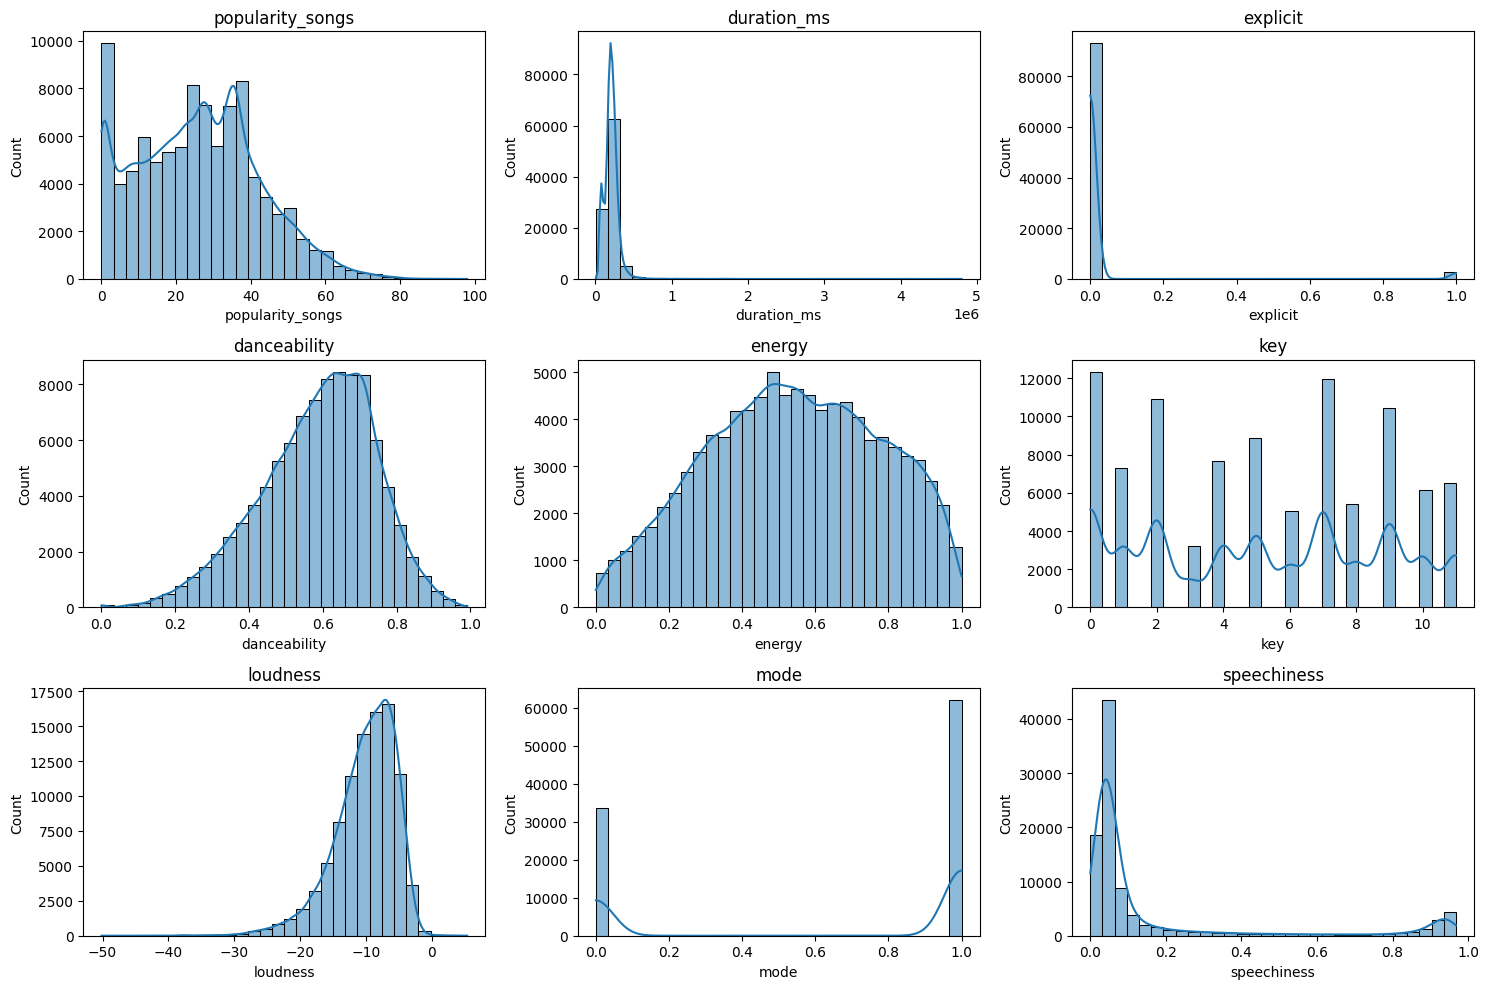

In [14]:
# 6. Explore feature distributions
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols[:9], 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


In [15]:
# 7. Feature selection
features = [
 'danceability','energy','loudness','speechiness','acousticness',
 'instrumentalness','liveness','valence','tempo','duration_ms'
]

X = df[features].copy()

# Optional: log-transform skewed feature
X['duration_ms'] = np.log1p(X['duration_ms'])


In [17]:
# 8. Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Save scaler for later use
joblib.dump(scaler, "../results/scaler.joblib")


['../results/scaler.joblib']

In [18]:
# 9. Save preprocessed dataset
df_clean = df.copy()
df_clean[features] = X_scaled
df_clean.to_csv("../results/clean_data.csv", index=False)

print("✅ Cleaned and scaled dataset saved to ../results/clean_data.csv")


✅ Cleaned and scaled dataset saved to ../results/clean_data.csv


In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_utils import preprocess

df_clean = preprocess(
    path="../data/raw/single_genre_artists.csv",
    save_clean="../results/clean_data.csv",
    save_scaler="../results/scaler.joblib"
)

df_clean.head()  # optional, just to preview


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,-0.311345,0,4AxgXfD7ISvJSTObqm4aIE,1922,-0.153476,-1.511128,4,...,1.616187,-0.353338,0.538584,0.321287,0.515005,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,0.368718,0,4AxgXfD7ISvJSTObqm4aIE,1922,-1.028518,-1.528056,10,...,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,0.221609,0,4AxgXfD7ISvJSTObqm4aIE,1922,-0.488051,-1.418027,0,...,1.622240,-0.353405,1.039046,-0.375943,-1.560003,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,-0.304798,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.573581,-0.313510,9,...,1.610134,-0.353405,-0.031836,0.611464,0.405268,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,-0.228190,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.406294,-1.028695,9,...,1.610134,-0.353405,0.796887,1.087031,-1.377593,4,5078.0,['vintage chanson'],Mistinguett,22
